<a href="https://colab.research.google.com/github/rafathaurnab/Data_Science_project/blob/main/main_cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

## Given codes from Assessment module
import pandas as pd

#Load dataset
df_original = pd.read_csv("/content/drive/MyDrive/ass02.csv")

#eep original unchanged
df= df_original.copy()


# Types & ordering
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dtype_map = {
    "Year":"int64",
    "Month":"int64",
    "Day_of_week":"category",
    "Day_type":"category",
    "Mode":"category"
}
df = df.astype({k:v for k,v in dtype_map.items() if k in df.columns})
df["Day_of_week"] = pd.Categorical(df["Day_of_week"], categories=dow_order, ordered=True)

# MonthStart for time series
df["MonthStart"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Period tagging
def era(y):
    if y < 2020: return "Pre-2020"
    if y <= 2021: return "2020-2021"
    return "Post-2021"

df["Period"] = df["Year"].apply(era)

# Rolling mean of patronage (by Mode & Day_type)
df = df.sort_values(["Mode","Day_type","MonthStart"])
df["Pax_3m_roll"] = df.groupby(["Mode","Day_type"])["Pax_daily"].transform(
    lambda s: s.rolling(3, min_periods=1).mean()
)



/tmp/ipykernel_8047/254981533.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Pax_3m_roll"] = df.groupby(["Mode","Day_type"])["Pax_daily"].transform(


In [ ]:

## Given codes from Assessment module
import pandas as pd

#Load dataset
df_original = pd.read_csv("/content/drive/MyDrive/ass02.csv")

#eep original unchanged
df= df_original.copy()


# Types & ordering
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dtype_map = {
    "Year":"int64",
    "Month":"int64",
    "Day_of_week":"category",
    "Day_type":"category",
    "Mode":"category"
}
df = df.astype({k:v for k,v in dtype_map.items() if k in df.columns})
df["Day_of_week"] = pd.Categorical(df["Day_of_week"], categories=dow_order, ordered=True)

# MonthStart for time series
df["MonthStart"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Period tagging
def era(y):
    if y < 2020: return "Pre-2020"
    if y <= 2021: return "2020-2021"
    return "Post-2021"

df["Period"] = df["Year"].apply(era)

# Rolling mean of patronage (by Mode & Day_type)
df = df.sort_values(["Mode","Day_type","MonthStart"])
df["Pax_3m_roll"] = df.groupby(["Mode","Day_type"])["Pax_daily"].transform(
    lambda s: s.rolling(3, min_periods=1).mean()
)



/tmp/ipykernel_8047/254981533.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Pax_3m_roll"] = df.groupby(["Mode","Day_type"])["Pax_daily"].transform(


In [3]:
# 1. Check basic info and data types
print("--- Data Info ---")
df.info()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4300 entries, 5 to 4284
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         4300 non-null   int64         
 1   Month        4300 non-null   int64         
 2   Month_name   4300 non-null   object        
 3   Day_of_week  4300 non-null   category      
 4   Day_type     4300 non-null   category      
 5   Mode         4300 non-null   category      
 6   Pax_daily    4300 non-null   int64         
 7   MonthStart   4300 non-null   datetime64[ns]
 8   Period       4300 non-null   object        
 9   Pax_3m_roll  4300 non-null   float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 282.0+ KB


In [5]:
# 2. Identify missing values across all columns
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Year           0
Month          0
Month_name     0
Day_of_week    0
Day_type       0
Mode           0
Pax_daily      0
MonthStart     0
Period         0
Pax_3m_roll    0
dtype: int64


In [6]:
# 3. Check for duplicate rows
print(f"\nDuplicate rows found: {df.duplicated().sum()}")


Duplicate rows found: 0


In [7]:
# 4. Statistical summary to find outliers or illogical values (e.g. negative pax)
df.describe()

,Year,Month,Pax_daily,MonthStart,Pax_3m_roll
count,4300.000000,4300.000000,4300.000000,4300,4300.000000
mean,2021.439535,6.551163,240732.313953,2021-11-25 09:49:23.720930304,240766.676357
min,2018.000000,1.000000,1900.000000,2018-01-01 00:00:00,2616.666667
25%,2019.000000,4.000000,37800.000000,2019-12-01 00:00:00,37666.666667
50%,2021.000000,7.000000,165375.000000,2021-12-01 00:00:00,166916.666667
75%,2023.000000,9.000000,406562.500000,2023-11-01 00:00:00,404741.666667
max,2025.000000,12.000000,927650.000000,2025-11-01 00:00:00,901666.666667
std,2.266255,3.383104,226797.336852,NaN,225068.779082


In [8]:
# 5. Check unique values for categorical consistency
categorical_columns = ['Mode', 'Day_type', 'Period']
for col in categorical_columns:
    print(f"\nUnique values in {col}: {df[col].unique()}")


Unique values in Mode: ['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']
Categories (5, object): ['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']

Unique values in Day_type: ['Normal Weekday', 'School Holiday Weekday', 'Weekend']
Categories (3, object): ['Normal Weekday', 'School Holiday Weekday', 'Weekend']

Unique values in Period: ['Pre-2020' '2020-2021' 'Post-2021']


## Phase 2: Data Cleaning
Applying fixes to the identified technical issues.

In [9]:
# 1. Create a unique Key ID and sort ascending
df.insert(0, 'id', range(1, len(df) + 1))
df.sort_values('id', ascending=True, inplace=True)

In [10]:
# 2. Drop redundant columns
df.drop(columns=['Month_name', 'Year', 'Month'], inplace=True)

In [11]:
#Move 'MonthStart' to the second place for better readability
col = df.pop('MonthStart')

df.insert(1, 'MonthStart', col)

In [12]:
# 3. Round rolling average decimals for better readability
df['Pax_3m_roll'] = df['Pax_3m_roll'].round(2)
df[['Pax_3m_roll']].head()

,Pax_3m_roll
5,308450.00
30,334125.00
40,356166.67
50,403233.33
55,437550.00


In [13]:
# Export cleaned
df.to_csv("cleaned_dataset.csv", index=False)

# **Analysis**

In [14]:
df_cleaned = pd.read_csv("cleaned_dataset.csv")

dfc = df_cleaned.copy()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# turning hte columns into lowercase for easy usage
df_cleaned.columns = [col.lower() for col in df_cleaned.columns]

Mode Summary Table

In [16]:

#summary by usin g group by to select particular columns to group within
#summary using the mode and pax_daily mean and median
summary_mode = df_cleaned.groupby('mode', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_mode.columns = ['mode', 'mean_pax_daily', 'median_pax_daily']
display(summary_mode)

,mode,mean_pax_daily,median_pax_daily
0,MetroBus,281974.709302,305975.0
1,MetroTrain,458138.139535,458400.0
2,RegionalBus,27079.302326,28950.0
3,RegionalTrain,39932.848837,41100.0
4,Tram,396536.569767,416325.0


Day_type Summary Table

In [38]:
#summary of day_type and pax_daily mean and median
summary_day_type = df_cleaned.groupby('day_type', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_day_type.columns = ['day_type', 'mean_pax_daily', 'median_pax_daily']
display(summary_day_type)

,day_type,mean_pax_daily,median_pax_daily
0,Normal Weekday,281347.196468,260050.0
1,School Holiday Weekday,238330.967742,195150.0
2,Weekend,146640.473684,122975.0


Day_of_week Summary Table

In [18]:
#summary of day_of_week and pax_daily mean and median
summary_day_of_week = df_cleaned.groupby('day_of_week', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_day_of_week.columns = ['day_of_week', 'mean_pax_daily', 'median_pax_daily']
display(summary_day_of_week)

,day_of_week,mean_pax_daily,median_pax_daily
0,Friday,264025.725191,232100.0
1,Monday,248087.067669,210700.0
2,Saturday,169497.789474,152900.0
3,Sunday,123783.157895,115300.0
4,Thursday,276469.044118,241150.0
5,Tuesday,270939.179104,223250.0
6,Wednesday,277055.220588,240200.0


Period Summary Table

In [40]:

summary_period = df_cleaned.groupby('period', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_period.columns = ['period', 'mean_pax_daily', 'median_pax_daily']
display(summary_period)

,period,mean_pax_daily,median_pax_daily
0,2020-2021,127440.312500,72700.0
1,Post-2021,252513.380952,272625.0
2,Pre-2020,335312.685185,331025.0


Trend **Lines**

In [20]:
#changing the dtype into a datetime format
df_cleaned['monthstart'] = pd.to_datetime(df_cleaned['monthstart'])

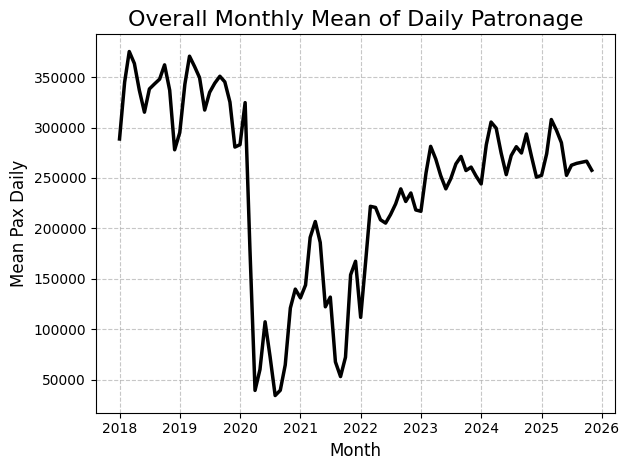

In [44]:
#overall graph for monthstart by pax_daily
#grouping the monthstart with pax_daily and then reseting the monthstart into a column with the reset_index() part
df_overall = df_cleaned.groupby('monthstart')['pax_daily'].mean().reset_index()

#seaborn visualizations were used with proper measurement
sns.lineplot(data=df_overall, x='monthstart', y='pax_daily', color='black', linewidth=2.5)
#labeling part for the visuals
plt.title('Overall Monthly Mean of Daily Patronage', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

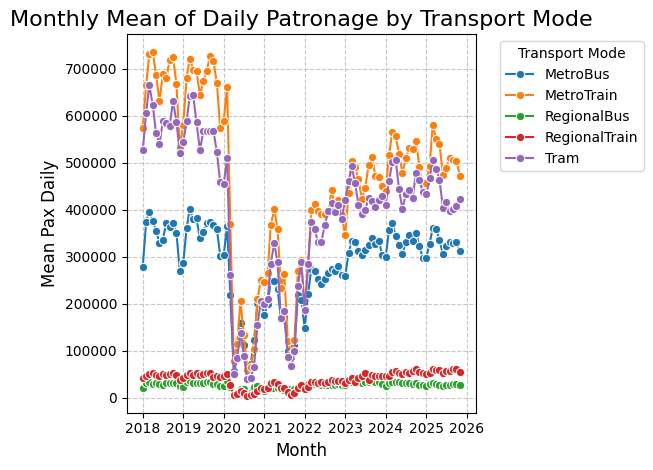

In [22]:
#multiple graph for monthstart by pax_daily based on the mode
df_mode_trend = df_cleaned.groupby(['monthstart', 'mode'], observed=False)['pax_daily'].mean().reset_index()

sns.lineplot(data=df_mode_trend, x='monthstart', y='pax_daily', hue='mode', marker='o')
#labeling for the visuals
plt.title('Monthly Mean of Daily Patronage by Transport Mode', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.legend(title='Transport Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Weekly Pattern Visuals**

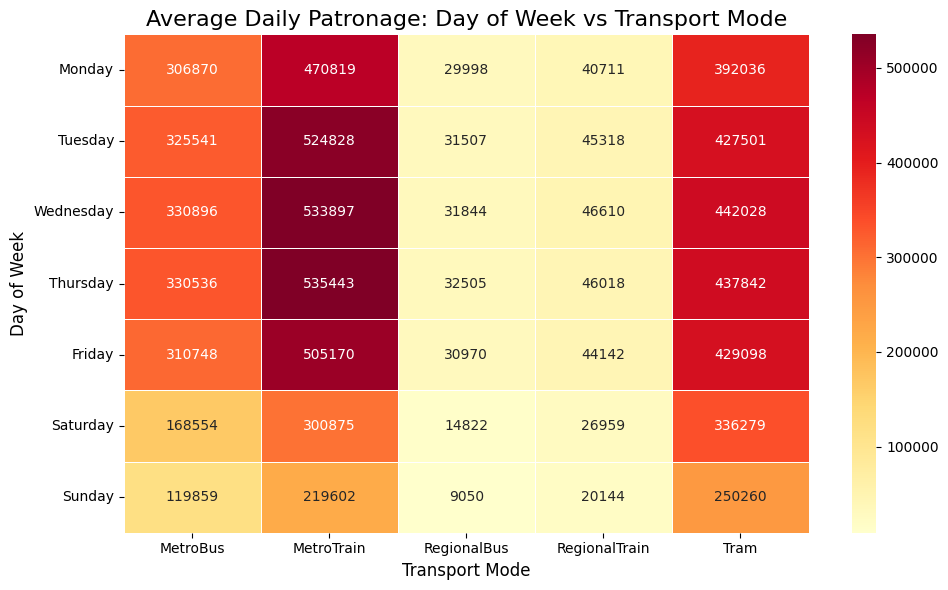

In [47]:
heatmap_data = df_cleaned.groupby(['day_of_week', 'mode'], observed=False)['pax_daily'].mean().unstack()

#defining the order for the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
#setting the heatmap to follow this order
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Daily Patronage: Day of Week vs Transport Mode', fontsize=16)
plt.ylabel('Day of Week', fontsize=12)
plt.xlabel('Transport Mode', fontsize=12)
plt.tight_layout()
plt.show()

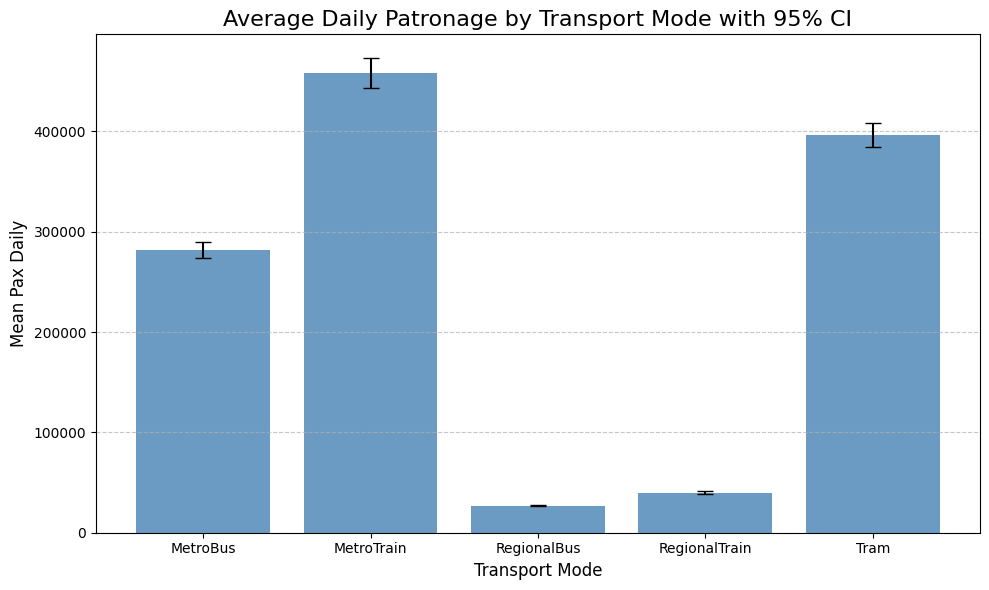

In [24]:
import numpy as np

summary = df_cleaned.groupby('mode', observed=False)['pax_daily'].agg(['mean', 'sem']).reset_index()
summary.columns = ['mode', 'mean_pax_daily', 'sem']
summary['ci95'] = summary['sem'] * 1.96

plt.figure(figsize=(10, 6))
plt.bar(summary['mode'], summary['mean_pax_daily'], yerr=summary['ci95'], capsize=6, color='steelblue', alpha=0.8)
plt.title('Average Daily Patronage by Transport Mode with 95% CI', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Transport Mode', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()

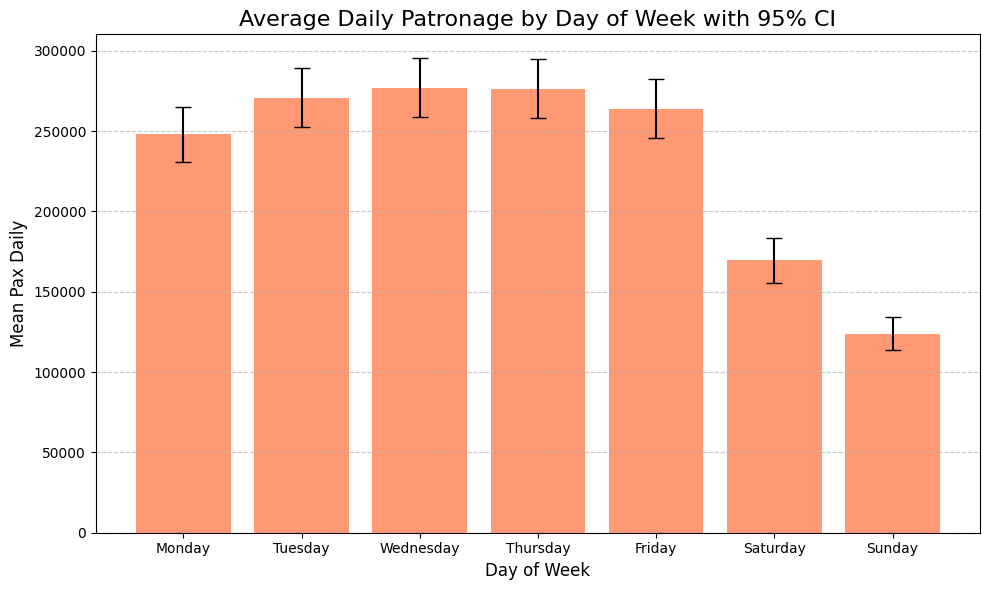

In [25]:
summary_dow = df_cleaned.groupby('day_of_week', observed=False)['pax_daily'].agg(['mean', 'sem']).reset_index()
summary_dow.columns = ['day_of_week', 'mean_pax_daily', 'sem']
summary_dow['ci95'] = summary_dow['sem'] * 1.96

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
summary_dow['day_of_week'] = pd.Categorical(summary_dow['day_of_week'], categories=day_order, ordered=True)
summary_dow = summary_dow.sort_values('day_of_week')

plt.figure(figsize=(10, 6))
plt.bar(summary_dow['day_of_week'], summary_dow['mean_pax_daily'], yerr=summary_dow['ci95'], capsize=6, color='coral', alpha=0.8)
plt.title('Average Daily Patronage by Day of Week with 95% CI', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Day of Week', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()

### Probability Distributions & Modelling (LO2)

Distribution check & normality diagonastics


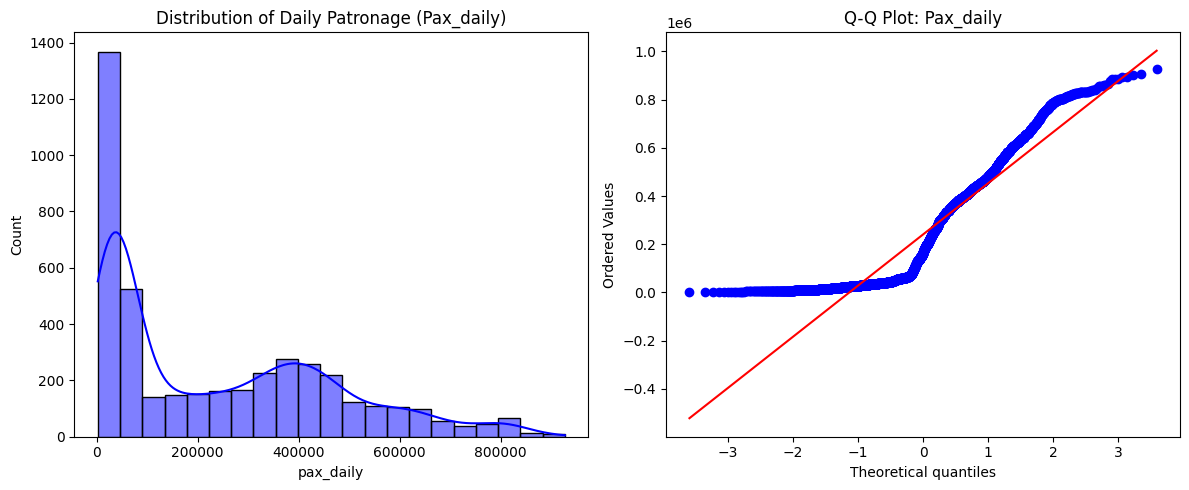

In [54]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution Checks: Histogram and KDE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['pax_daily'], kde=True, color='blue')
plt.title('Distribution of Daily Patronage (Pax_daily)')

# 2. Normality Diagnostics: Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(df_cleaned['pax_daily'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Pax_daily')
plt.tight_layout()
plt.show()

Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Prepare data: convert dates to numbers (ordinals) so the model can read them
df_trend = df_cleaned.copy()
df_trend['month_ordinal'] = df_trend['monthstart'].map(pd.Timestamp.toordinal)

modes = df_trend['mode'].unique()
print("--- Long-run Monthly Trend Estimates ---")

for m in modes:
    # Filter data for one mode at a time
    subset = df_trend[df_trend['mode'] == m]
    X = subset[['month_ordinal']]
    y = subset['pax_daily']

    # Fit the linear model
    model = LinearRegression().fit(X, y)

    # Convert the daily coefficient to a monthly estimate (approx 30 days)
    monthly_trend = model.coef_[0] * 30

    print(f"{m:15}: {'Growth' if monthly_trend > 0 else 'Decline'} of {abs(monthly_trend):.2f} passengers/month")

--- Long-run Monthly Trend Estimates ---
MetroBus       : Growth of 269.98 passengers/month
MetroTrain     : Decline of 1205.96 passengers/month
RegionalBus    : Growth of 42.35 passengers/month
RegionalTrain  : Growth of 164.39 passengers/month
Tram           : Decline of 755.06 passengers/month


probabilty statement

In [28]:
# Probability statement: estimate prob that Pax_daily > Threshold for MetroTrain on Normal Weekday
# Threshold defined as 600,000 for demonstration
threshold = 600000
mode_choice = 'MetroTrain'

subset_prob = df_cleaned[(df_cleaned['mode'] == mode_choice) & (df_cleaned['day_type'] == 'Normal Weekday')]

# Calculate empirical probability
count_exceed = len(subset_prob[subset_prob['pax_daily'] > threshold])
total_count = len(subset_prob)
prob_empirical = count_exceed / total_count

# Calculate theoretical probability assuming Normal Distribution
mean_val = subset_prob['pax_daily'].mean()
std_val = subset_prob['pax_daily'].std()
z_score = (threshold - mean_val) / std_val
prob_theoretical = 1 - stats.norm.cdf(z_score)

print(f"--- Operational Probability Analysis for {mode_choice} ---")
print(f"Threshold: {threshold} passengers")
print(f"Empirical Probability: {prob_empirical:.2%}")
print(f"Theoretical Probability (Normal Dist): {prob_theoretical:.2%}")

--- Operational Probability Analysis for MetroTrain ---
Threshold: 600000 passengers
Empirical Probability: 39.96%
Theoretical Probability (Normal Dist): 39.62%


#### Interpretation for Decision-Makers

**1. Distribution Analysis:**
The Q-Q plot and Histogram indicate whether the patronage follows a normal distribution. Significant deviations from the diagonal line in the Q-Q plot suggest skewness or heavy tails, which informs the choice of robust statistical methods.

**2. Trend Modeling:**
The linear regression coefficients provide the average growth or decline in patronage per month. For example, a positive slope indicates a growing demand for that transport mode over time, while a negative slope suggests declining usage.

**3. Probability Statement:**
Estimating the probability of exceeding an operational threshold (e.g., 600,000 for MetroTrain) helps in capacity planning. If the probability is high (e.g., > 20%), decision-makers should consider increasing frequency or vehicle capacity on normal weekdays to avoid overcrowding.

In [29]:
import scipy.stats as stats
import numpy as np

# Filter for MetroBus
mode_interest = 'MetroBus'

group_weekday = df_cleaned[(df_cleaned['mode'] == mode_interest) & (df_cleaned['day_type'] == 'Normal Weekday')]['pax_daily']
group_weekend = df_cleaned[(df_cleaned['mode'] == mode_interest) & (df_cleaned['day_type'] == 'Weekend')]['pax_daily']

print(f"--- Descriptive Statistics for {mode_interest} ---")
print(f"Normal Weekday Mean: {group_weekday.mean():.2f} (n={len(group_weekday)})")
print(f"Weekend Mean: {group_weekend.mean():.2f} (n={len(group_weekend)})")

# Perform Welch's t-test
t_stat, p_val = stats.ttest_ind(group_weekday, group_weekend, equal_var=False)

# Calculate 95% Confidence Interval for the difference in means
n1, n2 = len(group_weekday), len(group_weekend)
mean1, mean2 = group_weekday.mean(), group_weekend.mean()
std1, std2 = group_weekday.std(), group_weekend.std()

se_diff = np.sqrt((std1**2/n1) + (std2**2/n2))
df_welch = (std1**2/n1 + std2**2/n2)**2 / ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df_welch)

mean_diff = mean1 - mean2
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

# Cohen's d for Effect Size
pool_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
cohens_d = mean_diff / pool_std

print(f"\n--- Inferential Statistics ---")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")
print(f"95% CI for Difference (Weekday - Weekend): [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Effect Size (Cohen's d): {cohens_d:.4f}")

--- Descriptive Statistics for MetroBus ---
Normal Weekday Mean: 344031.24 (n=453)
Weekend Mean: 144206.58 (n=190)

--- Inferential Statistics ---
t-statistic: 32.6437, p-value: 3.1276e-138
95% CI for Difference (Weekday - Weekend): [187804.17, 211845.14]
Effect Size (Cohen's d): 2.1331


# **Inferential Statistics**

### Weekday vs Weekend Comparison: Two-sample t-test (MetroBus)






This section performs three key analyses:
1. **Weekday vs Weekend Comparison** (Two-sample t-test/Mann-Whitney)
2. **Mode Comparison on Normal Weekdays** (ANOVA/Kruskal-Wallis)
3. **Pre-2020 vs Post-2021 Comparison** (Two-sample t-test with CI)

We will justify the use of parametric or non-parametric tests based on normality (Shapiro-Wilk) and variance (Levene's) checks.

In [55]:
import scipy.stats as stats
import numpy as np

# 1. Weekday vs Weekend comparison for MetroBus
mode_choice = 'MetroBus'
weekday_pax = df_cleaned[(df_cleaned['mode'] == mode_choice) & (df_cleaned['day_type'] == 'Normal Weekday')]['pax_daily']
weekend_pax = df_cleaned[(df_cleaned['mode'] == mode_choice) & (df_cleaned['day_type'] == 'Weekend')]['pax_daily']

# Assumption Checks
_, p_norm_wd = stats.shapiro(weekday_pax)
_, p_norm_we = stats.shapiro(weekend_pax)
_, p_lev = stats.levene(weekday_pax, weekend_pax)

print(f"--- {mode_choice}: Weekday vs Weekend ---")
print(f"Normality p-values: Weekday={p_norm_wd:.4f}, Weekend={p_norm_we:.4f}")
print(f"Levene's Variance p-value: {p_lev:.4f}")

# Justification: If p < 0.05, we use Mann-Whitney U due to non-normality
if p_norm_wd < 0.05 or p_norm_we < 0.05:
    stat, p_val = stats.mannwhitneyu(weekday_pax, weekend_pax)
    print(f"Justification: Non-parametric Mann-Whitney U used due to non-normal distribution.")
    print(f"U-stat: {stat}, p-value: {p_val:.4e}")
else:
    stat, p_val = stats.ttest_ind(weekday_pax, weekend_pax, equal_var=(p_lev > 0.05))
    print(f"Justification: T-test used.")
    print(f"t-stat: {stat}, p-value: {p_val:.4e}")

--- MetroBus: Weekday vs Weekend ---
Normality p-values: Weekday=0.0000, Weekend=0.0001
Levene's Variance p-value: 0.0000
Justification: Non-parametric Mann-Whitney U used due to non-normal distribution.
U-stat: 78545.5, p-value: 2.5321e-61


In [56]:
# 2. Differences across Modes on Normal Weekdays
df_normal = df_cleaned[df_cleaned['day_type'] == 'Normal Weekday']
mode_groups = [df_normal[df_normal['mode'] == m]['pax_daily'] for m in df_normal['mode'].unique()]

# Assumption Checks
_, p_lev_anova = stats.levene(*mode_groups)
print(f"\n--- Mode Comparison (Normal Weekdays) ---")
print(f"Levene's Variance p-value: {p_lev_anova:.4f}")

# Justification: Due to unequal variances and non-normality in daily patronage, Kruskal-Wallis is robust.
if p_lev_anova < 0.05:
    h_stat, p_kruskal = stats.kruskal(*mode_groups)
    print("Justification: Kruskal-Wallis used because variances are not equal (Homoscedasticity failed).")
    print(f"H-statistic: {h_stat:.3f}, p-value: {p_kruskal:.4e}")
else:
    f_stat, p_anova = stats.f_oneway(*mode_groups)
    print("Justification: One-way ANOVA used.")
    print(f"F-statistic: {f_stat:.3f}, p-value: {p_anova:.4e}")


--- Mode Comparison (Normal Weekdays) ---
Levene's Variance p-value: 0.0000
Justification: Kruskal-Wallis used because variances are not equal (Homoscedasticity failed).
H-statistic: 1737.785, p-value: 0.0000e+00


In [57]:
# 3. Pre-2020 vs Post-2021 (MetroTrain, Normal Weekday)
group_pre = df_cleaned[(df_cleaned['mode'] == 'MetroTrain') & (df_cleaned['day_type'] == 'Normal Weekday') & (df_cleaned['period'] == 'Pre-2020')]['pax_daily']
group_post = df_cleaned[(df_cleaned['mode'] == 'MetroTrain') & (df_cleaned['day_type'] == 'Normal Weekday') & (df_cleaned['period'] == 'Post-2021')]['pax_daily']

# Welch's T-Test (Robust to unequal variance and large samples)
t_stat, p_val = stats.ttest_ind(group_pre, group_post, equal_var=False)

# CI Calculation
n1, n2 = len(group_pre), len(group_post)
mean_diff = group_pre.mean() - group_post.mean()
se_diff = np.sqrt(group_pre.var()/n1 + group_post.var()/n2)
ci = stats.t.interval(0.95, df=n1+n2-2, loc=mean_diff, scale=se_diff)

print(f"\n--- MetroTrain: Pre-2020 vs Post-2021 ---")
print(f"Justification: Welch's T-test used to compare means without assuming equal variance.")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")
print(f"95% Confidence Interval for Mean Difference: [{ci[0]:.2f}, {ci[1]:.2f}]")


--- MetroTrain: Pre-2020 vs Post-2021 ---
Justification: Welch's T-test used to compare means without assuming equal variance.
t-statistic: 37.6731, p-value: 3.5021e-122
95% Confidence Interval for Mean Difference: [251300.13, 278988.39]
